In [1]:
## Stochastic Simulation - Day 2

# Part 1: Generate observations from a geometric distribution by converting uniform random numbers to geometric random numbers 
#         by using a formmula.
# Part 2: Generate observations from a wierd distribution but this time there is no formula to convert the uniform random numbers 
#         to the desired distribution. Instead, we will use three different methods that works for converting uniform random numbers
#         to almost any discrete distribution.


Maximum value of x_small: 59.0
Maximum value of x_medium: 14.0
Maximum value of x_large: 6.0


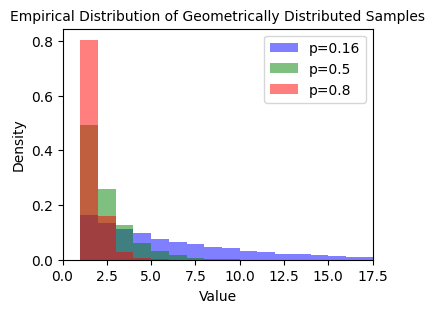

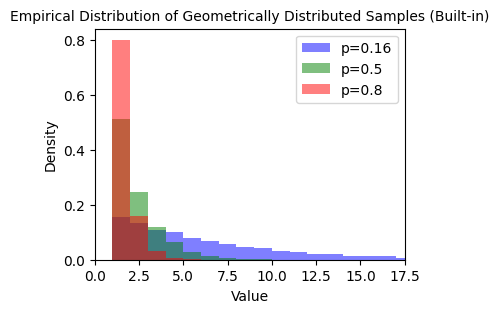

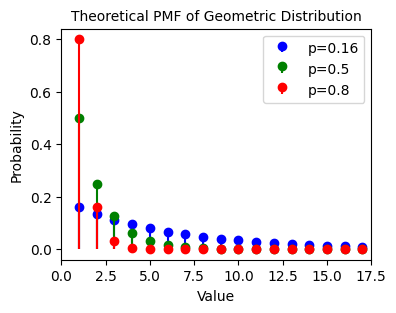

In [2]:
# Exercise 2 - Part 1

import numpy as np
import matplotlib.pyplot as plt

# Drawing 10 000 samples from a geometric distribution with 3 parameter values
p_small = 0.16
p_medium = 0.5
p_large = 0.8

############################ METHOD 1 ############################
# Drawing 10 000 samples from a uniform distribution on [0,1]
u_small = np.random.uniform(0, 1, size=10000)
u_medium = np.random.uniform(0, 1, size=10000)
u_large = np.random.uniform(0, 1, size=10000)

# Using the theoretical formula to convert the uniform samples to geometric samples
x_small = np.floor(np.log(u_small)/np.log(1-p_small))+1
x_medium = np.floor(np.log(u_medium)/np.log(1-p_medium))+1
x_large = np.floor(np.log(u_large)/np.log(1-p_large))+1

print("Maximum value of x_small:", np.max(x_small))
print("Maximum value of x_medium:", np.max(x_medium))
print("Maximum value of x_large:", np.max(x_large))

###################################################################

############################ METHOD 2 ############################
# Alternatively, we can use the built-in numpy function to generate geometric samples
x_small_builtin = np.random.geometric(p_small, size=10000)
x_medium_builtin = np.random.geometric(p_medium, size=10000)
x_large_builtin = np.random.geometric(p_large, size=10000)

###################################################################

############################ METHOD 3 ############################
# Theoretical pmf of the geometric distribution
n = np.arange(1, 20)
pmf_small = (1-p_small)**(n-1) * p_small
pmf_medium = (1-p_medium)**(n-1) * p_medium
pmf_large = (1-p_large)**(n-1) * p_large

###################################################################

# Method 1: Plotting the empirical distribution of the samples
plt.figure(figsize=(4, 3))
plt.hist(x_small, bins=np.arange(1, max(x_small)+1), density=True, alpha=0.5, label=f'p={p_small}', color='blue')
plt.hist(x_medium, bins=np.arange(1, max(x_medium)+1), density=True, alpha=0.5, label=f'p={p_medium}', color='green')
plt.hist(x_large, bins=np.arange(1, max(x_large)+1), density=True, alpha=0.5, label=f'p={p_large}', color='red')
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Empirical Distribution of Geometrically Distributed Samples", fontsize=10)
plt.legend()
plt.xlim(0, 17.5)
plt.show()

# Method 2: Plotting the empirical distribution of the samples generated by the built-in function
plt.figure(figsize=(4, 3))
plt.hist(x_small_builtin, bins=np.arange(1, max(x_small_builtin)+1), density=True, alpha=0.5, label=f'p={p_small}', color='blue')
plt.hist(x_medium_builtin, bins=np.arange(1, max(x_medium_builtin)+1), density=True, alpha=0.5, label=f'p={p_medium}', color='green')
plt.hist(x_large_builtin, bins=np.arange(1, max(x_large_builtin)+1), density=True, alpha=0.5, label=f'p={p_large}', color='red')
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Empirical Distribution of Geometrically Distributed Samples (Built-in)", fontsize=10)
plt.legend()
plt.xlim(0, 17.5)
plt.show()

# Method 3: Plotting the theoretical pmf of the geometric distribution
plt.figure(figsize=(4, 3))
plt.stem(n, pmf_small, label=f'p={p_small}', linefmt='blue', markerfmt='bo', basefmt=' ')
plt.stem(n, pmf_medium, label=f'p={p_medium}', linefmt='green', markerfmt='go', basefmt=' ')
plt.stem(n, pmf_large, label=f'p={p_large}', linefmt='red', markerfmt='ro', basefmt=' ')
plt.xlabel("Value")
plt.ylabel("Probability")
plt.title("Theoretical PMF of Geometric Distribution", fontsize=10)
plt.legend()
plt.xlim(0, 17.5)
plt.show()

Observation: increasing p makes waiting time shorter.

In [ ]:
# The chi-square test checks whether the entire distribution matches the theoretical geometric distribution.
from scipy.stats import chisquare

# Total number of simulated observations
N = len(x_small)
print("Total number of simulated observations:", N)

# OBSERVED FREQUENCIES

# We use the categories:
# 1, 2, 3, ..., 9, and 10+

observed = []

for k in range(1, 10):
    observed.append(np.sum(x_small == k)) # Count how many times each value occurs in the simulation.

# Count all observations with X >= 10
observed.append(np.sum(x_small >= 10))

# The last category groups together all values greater than
# or equal to 10. This is necessary because the geometric
# distribution has infinitely many possible values, while
# the chi-square test requires a finite number of categories.

observed = np.array(observed)


# THEORETICAL PROBABILITIES

# For a geometric distribution:
# P(X = k) = (1-p)^(k-1) * p

expected_probs = []

for k in range(1, 10):
    expected_probs.append((1 - p_small)**(k - 1) * p_small)


# TAIL PROBABILITY

# The last category is X >= 10.

# For a geometric distribution:
# P(X >= 10) = probability of surviving the first 9 trials = (1-p)^9

expected_probs.append((1 - p_small)**9)

expected_probs = np.array(expected_probs)


# EXPECTED FREQUENCIES

# Expected count = N * probability

expected = N * expected_probs
#print(len(expected))


# CHI-SQUARE GOODNESS-OF-FIT TEST

# H0: The data follow a geometric distribution with parameter p_small.
# H1: The data do not follow a geometric distribution with parameter p_small.


chi2_stat, p_value = chisquare(observed, expected)

# PRINT RESULTS 
print("Observed frequencies:")
print(observed)

print("\nExpected frequencies:")
print(expected)

print("\nChi-square statistic =", chi2_stat)
print("p-value =", p_value)


#Because p_value > 0.05:
print("\nFail to reject H0.")
print("The simulated data is significantly consistent with the theoretical geometric distribution.")




Total number of simulated observations: 10000
10
Observed frequencies:
[1629 1348 1141  994  761  650  589  483  422 1983]

Expected frequencies:
[1600.         1344.         1128.96        948.3264      796.594176
  669.13910784  562.07685059  472.14455449  396.60142577 2082.15748531]

Chi-square statistic = 12.891412003172823
p-value = 0.16758162932832424

Fail to reject H0.
The simulated data is significantly consistent with the theoretical geometric distribution.


In [40]:
# Exercise 2 - Part 2

Now we consider a six-point distribution, but with unequal probabilities:

\begin{equation}
x_i = 1,2,3,4,5,6
\end{equation}


\begin{equation}
p_i = \Bigg( \frac{7}{8}, \frac{5}{8}, \frac{1}{8}, \frac{1}{8}, \frac{1}{8}, \frac{5}{8} \Bigg)
\end{equation}

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# Values and probabilities from the slide
x_values = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

# Number of observations
N = 10000

# DIRECT METHOD
def direct_method(x_values, p, N):
    # Compute cumulative probabilities. This corresponds to the interval endpoints. 
    cumulative_p = np.cumsum(p)

    # Generate uniform random numbers
    U = np.random.uniform(0, 1, size=N)

    # For each U, find the first cumulative probability larger than U
    indices = np.searchsorted(cumulative_p, U)

    # Return corresponding x-values
    return x_values[indices]

samples_direct = direct_method(x_values, p, N)
#print("Direct method samples:", samples_direct)

# REJECTION METHOD
def rejection_method(x_values, p, N): 
    k = len(x_values) #number of possible outcomes

    # c must be at least as large as the largest probability
    c = np.max(p)+0.01

    samples = []

    while len(samples) < N: # keeps repeating until we have N accepted samples 
        # Step 1: propose an index uniformly from 0,...,k-1
        I = np.random.randint(0, k) # generates a random interger of either 0,1,2,3,4,5 with equal probability

        # Step 2: generate U
        U = np.random.uniform(0, 1)

        # Accept with probability p[I] / c
        if U <= p[I] / c:
            samples.append(x_values[I]) # if the proposal is accepted, the corresponding x-value is added to the list of samples

    return np.array(samples)

samples_rejection = rejection_method(x_values, p, N)
#print("Rejection method samples:", samples_rejection)

# ALIAS METHOD
def create_alias_table(p):
    k = len(p)

    # Scale probabilities by k
    scaled_p = p * k

    # Tables
    prob = np.zeros(k)
    alias = np.zeros(k, dtype=int)

    # Split into small and large probabilities
    small = list(np.where(scaled_p < 1)[0])
    large = list(np.where(scaled_p >= 1)[0])

    # Build alias table
    while small and large:
        s = small.pop()
        l = large.pop()

        prob[s] = scaled_p[s]
        alias[s] = l

        scaled_p[l] = scaled_p[l] - (1 - scaled_p[s])

        if scaled_p[l] < 1:
            small.append(l)
        else:
            large.append(l)

    # Remaining probabilities are exactly 1
    for i in small + large:
        prob[i] = 1

    return prob, alias


def alias_method(x_values, p, N):
    k = len(x_values)

    # Preprocessing step
    prob, alias = create_alias_table(p)

    samples = []

    for _ in range(N):
        # Choose a column uniformly
        I = np.random.randint(0, k)

        U = np.random.uniform(0, 1)

        if U <= prob[I]:
            samples.append(x_values[I])
        else:
            samples.append(x_values[alias[I]])

    return np.array(samples)

samples_alias = alias_method(x_values, p, N)


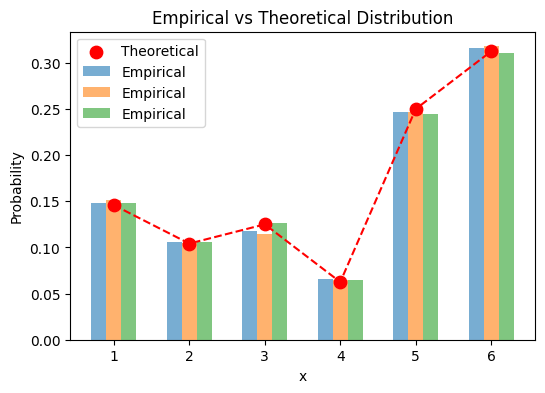


Chi-square statistic for Direct Method = 0.0007388880000000009
p-value for Direct Method = 0.9999999992108115

Chi-square statistic for Rejection Method = 0.001274065142857144
p-value for Rejection Method = 0.9999999969194358

Chi-square statistic for Alias Method = 0.00032476228571428657
p-value for Alias Method = 0.999999999898909


In [ ]:
# Comparing the three methods and computing the chi-square statistic for each method

# Generate samples using one of the methods
samples1 = samples_direct
samples2 = samples_rejection
samples3 = samples_alias

# Empirical probabilities
empirical_probs1 = [np.mean(samples1 == x) for x in x_values]
empirical_probs2 = [np.mean(samples2 == x) for x in x_values]
empirical_probs3 = [np.mean(samples3 == x) for x in x_values]

plt.figure(figsize=(6,4))

bar_with = 0.2

# Histogram of all three empirical probabilities
plt.bar(x_values - bar_with, empirical_probs1,
        width=bar_with,
        alpha=0.6,
        label="Empirical")
plt.bar(x_values, empirical_probs2,
        width=bar_with,
        alpha=0.6,
        label="Empirical")
plt.bar(x_values + bar_with, empirical_probs3,
        width=bar_with,
        alpha=0.6,
        label="Empirical")

# Theoretical probabilities as red points
plt.scatter(x_values, p,
            color='red',
            s=80,
            zorder=5,
            label="Theoretical")

# Optional: connect the points
plt.plot(x_values, p,
         color='red',
         linestyle='--')

plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Empirical vs Theoretical Distribution")
plt.legend()
plt.show()

chi2_stat1, p_value1 = chisquare(empirical_probs1, p)
chi2_stat2, p_value2 = chisquare(empirical_probs2, p)
chi2_stat3, p_value3 = chisquare(empirical_probs3, p)

print("\nChi-square statistic for Direct Method =", chi2_stat1)
print("p-value for Direct Method =", p_value1)

print("\nChi-square statistic for Rejection Method =", chi2_stat2)
print("p-value for Rejection Method =", p_value2)

print("\nChi-square statistic for Alias Method =", chi2_stat3)
print("p-value for Alias Method =", p_value3)

Observation: high-probability values survive more often, low-probability values are thrown away more often. 
Larger c results in more rejections, i.e. more iterations. 

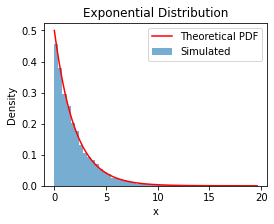

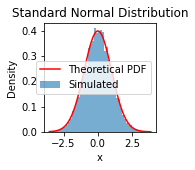

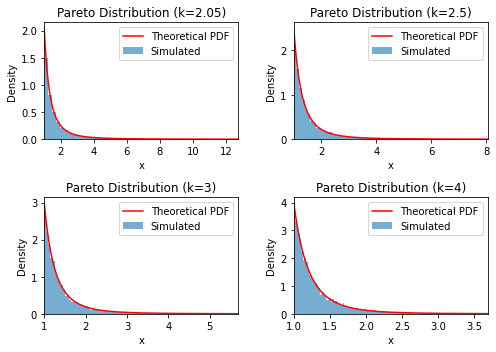

KS Test for Exponential Distribution: KS Statistic = 0.0063, p-value = 0.8214
KS Test for Standard Normal Distribution: KS Statistic = 0.0054, p-value = 0.9291
KS Test for Pareto Distribution (k=2.05): KS Statistic = 0.0063, p-value = 0.8214
KS Test for Pareto Distribution (k=2.5): KS Statistic = 0.0063, p-value = 0.8214
KS Test for Pareto Distribution (k=3): KS Statistic = 0.0063, p-value = 0.8214
KS Test for Pareto Distribution (k=4): KS Statistic = 0.0063, p-value = 0.8214
KS test for Pareto (k =2.05, beta =1) : D =0.0074 , p - value =0.6343
KS test for Pareto (k =2.5, beta =1) : D =0.0078 , p - value =0.5784
KS test for Pareto (k =3, beta =1) : D =0.0056 , p - value =0.9134
KS test for Pareto (k =4, beta =1) : D =0.0079 , p - value =0.5521


In [ ]:
# Exercise 3 - Part 1
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generate simulated observations from three different distributions starting from uniform random numbers.

N = 10000
U = np.random.uniform(0, 1, size=N)

# EXPONENTIAL DISTRIBUTION
lambda_exp = 0.5
samples_exp = -np.log(U) / lambda_exp

# NORMAL DISTRIBUTION (using the Box-Muller method)
U1 = np.random.uniform(0,1, size=N//2)
U2 = np.random.uniform(0,1, size=N//2)

multiplier = np.sqrt(-2*np.log(U1))
theta = 2*np.pi*U2

Z1 = multiplier * np.cos(theta)
Z2 = multiplier * np.sin(theta)

samples_normal = np.concatenate((Z1, Z2)) 

# PARETO DISTRIBUTION WITH BETA=1 (experiment with different values of k; k=2.05, k=2.5, k=3, k=4)
beta = 1
k_values = [2.05, 2.5, 3, 4]

samples_pareto = np.zeros((len(k_values), N))

for i, k in enumerate(k_values):
    samples_pareto[i, :] = (beta * (U**(-1/k)))


# EXPONENTIAL
x = np.linspace(0, np.max(samples_exp), N)
pdf_exp = lambda_exp * np.exp(-lambda_exp * x)

plt.figure(figsize=(4,3))
plt.hist(samples_exp, bins=50, density=True, alpha=0.6, label="Simulated")
plt.plot(x, pdf_exp, 'r', label="Theoretical PDF")
plt.title("Exponential Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()

# NORMAL
x = np.linspace(np.min(samples_normal), np.max(samples_normal), N)
pdf_norm = stats.norm.pdf(x, loc=0, scale=1)

plt.figure(figsize=(2,2))
plt.hist(samples_normal, bins=50, density=True, alpha=0.6, label="Simulated")
plt.plot(x, pdf_norm, 'r', label="Theoretical PDF")
plt.title("Standard Normal Distribution")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()


# PARETO — ALL k VALUES
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()   

for idx, k in enumerate(k_values):
    ax = axes[idx]
    X_pareto = samples_pareto[idx, :]

    # Histogram
    ax.hist(X_pareto, bins=500, density=True, alpha=0.6, label="Simulated")

    # Theoretical PDF
    x = np.linspace(beta, np.percentile(X_pareto, 99.5), N)
    pdf_pareto = k * beta**k / x**(k + 1)
    ax.plot(x, pdf_pareto, 'r', label="Theoretical PDF")

    ax.set_xlim(beta, np.percentile(X_pareto, 99.5))

    ax.set_title(f"Pareto Distribution (k={k})")
    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()


# KS TEST FOR ALL THREE DISTRIBUTIONS
# Exponential
ks_stat_exp, p_value_exp = stats.kstest(samples_exp, 'expon', args=(0, 1/lambda_exp))
print(f"KS Test for Exponential Distribution: KS Statistic = {ks_stat_exp:.4f}, p-value = {p_value_exp:.4f}")


# Normal
ks_stat_norm, p_value_norm = stats.kstest(samples_normal, 'norm')
print(f"KS Test for Standard Normal Distribution: KS Statistic = {ks_stat_norm:.4f}, p-value = {p_value_norm:.4f}")

# Pareto
for i, k in enumerate(k_values):
    ks_stat_pareto, p_value_pareto = stats.kstest(samples_pareto[i, :], 'pareto', args=(k, 0, beta))
    print(f"KS Test for Pareto Distribution (k={k}): KS Statistic = {ks_stat_pareto:.4f}, p-value = {p_value_pareto:.4f}")



In [22]:
# Exercise 3 - Part 2

# PARETO DISTRIBUTION WITH SUPPORT ON BETA=[0, infinity]. Compare the simulated sample mean and variance with their theoretical values.
N = 10000
beta = 1
k_values = [2.05, 2.5, 3, 4]

U = np.random.uniform(0, 1, size=N)

for k in k_values:
    sample = (beta * (U**(-1/k)))

    sample_mean = np.mean(sample)
    sample_variance = np.var(sample)

    theoretical_mean = beta * k / (k - 1)
    theoretical_variance = (beta**2 * k) / ((k - 1)**2 * (k - 2))

    print(f"Pareto Distribution (k={k}):")
    print(f"Sample Mean = {sample_mean:.4f}, Theoretical Mean = {theoretical_mean:.4f}")
    print(f"Sample Variance = {sample_variance:.4f}, Theoretical Variance = {theoretical_variance:.4f}\n")


# Discrepancy in the variance for k=2.05 is due to the fact that the theoretical variance is very large for k <= 2.



Pareto Distribution (k=2.05):
Sample Mean = 1.9801, Theoretical Mean = 1.9524
Sample Variance = 6.1756, Theoretical Variance = 37.1882

Pareto Distribution (k=2.5):
Sample Mean = 1.6840, Theoretical Mean = 1.6667
Sample Variance = 1.8230, Theoretical Variance = 2.2222

Pareto Distribution (k=3):
Sample Mean = 1.5115, Theoretical Mean = 1.5000
Sample Variance = 0.7409, Theoretical Variance = 0.7500

Pareto Distribution (k=4):
Sample Mean = 1.3397, Theoretical Mean = 1.3333
Sample Variance = 0.2345, Theoretical Variance = 0.2222



In [ ]:
# Exercise 3 - Part 3

# Generate 100 95% confidence intervals for the normal distribution (still using Box Muller) for the mean and the variance. 

import numpy as np
from scipy import stats

N = 10
confidence_intervals_mean = []
confidence_intervals_variance = []

for i in range(100):
    U1 = np.random.uniform(0,1, size=N//2)
    U2 = np.random.uniform(0,1, size=N//2)

    multiplier = np.sqrt(-2*np.log(U1))
    theta = 2*np.pi*U2

    Z1 = multiplier * np.cos(theta)
    Z2 = multiplier * np.sin(theta)

    sample_normal = np.concatenate((Z1, Z2)) 

    # Sample mean and variance
    sample_mean = np.mean(sample_normal)
    sample_variance = np.var(sample_normal, ddof=1)

    # Confidence interval for the mean 
    t_critical = stats.t.ppf(0.975, df=N-1)  # two-tailed test
    margin_of_error_mean = t_critical * np.sqrt(sample_variance / N)
    ci_mean = (sample_mean - margin_of_error_mean, sample_mean + margin_of_error_mean)
    confidence_intervals_mean.append(ci_mean)

    # Confidence interval for the variance
    chi2_lower = stats.chi2.ppf(0.025, df=N-1)
    chi2_upper = stats.chi2.ppf(0.975, df=N-1)
    
    ci_variance_lower = (N - 1) * sample_variance / chi2_upper
    ci_variance_upper = (N - 1) * sample_variance / chi2_lower
    ci_variance = (ci_variance_lower, ci_variance_upper)
    confidence_intervals_variance.append(ci_variance)

true_mean = 0
true_variance = 1

# Count how many CIs contain the true mean
count_mean = sum(
    (ci[0] <= true_mean <= ci[1]) 
    for ci in confidence_intervals_mean
)

# Count how many CIs contain the true variance
count_variance = sum(
    (ci[0] <= true_variance <= ci[1]) 
    for ci in confidence_intervals_variance
)

observed_coverage_mean = count_mean / 100
observed_coverage_variance = count_variance / 100

print(f"Average confidence interval for the mean: {np.mean(confidence_intervals_mean, axis=0)}")
print(f"Average confidence interval for the variance: {np.mean(confidence_intervals_variance, axis=0)}")
print(f"Observed coverage (mean): {observed_coverage_mean:.3f}")
print(f"Observed coverage (variance): {observed_coverage_variance:.3f}")



Average confidence interval for the mean: [-0.70738619  0.72325462]
Average confidence interval for the variance: [0.49642603 3.49704997]
Observed coverage (mean): 0.950
Observed coverage (variance): 0.970


Shape of X_direct: (10000,)
Shape of X_comp: (10000,)


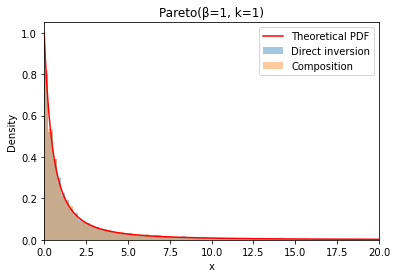

KS statistic between direct and composition: 0.0119, p-value: 0.4784


In [96]:
# Exercise 3 - Part 4

from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

k = 1
beta = 1

np.random.seed(42)

X_direct = np.zeros(N)
# Direct inversion method
U = np.random.uniform(0, 1, size=N)
X_direct = beta * (U ** (-1 / k)-1) 

# Composition method
U_exp = np.random.uniform(0, 1, size=N)
Y = -np.log(U_exp) / k  


X_comp = np.zeros(N)

U_exp = np.random.uniform(0, 1, size=N)
for i in range(N):
    X_comp[i] = -np.log(U_exp[i]) / Y[i]

print("Shape of X_direct:", X_direct.shape)
print("Shape of X_comp:", X_comp.shape)

edges = np.linspace(0,50,201)

x = np.linspace(0, np.percentile(X_comp, 99.5), N)
pdf_pareto = k / (k+x)**2

# Plotting
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(X_direct, bins=edges, density=True, alpha=0.4, label="Direct inversion")
ax.hist(X_comp, bins=edges, density=True, alpha=0.4, label="Composition")
ax.plot(x, pdf_pareto, 'r', label="Theoretical PDF")
ax.set_xlim(0, 20)
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title(f"Pareto(β={beta}, k={k})")
ax.legend()
plt.savefig("pareto_comparison.png", dpi=300)
plt.show()

ks_between = stats.ks_2samp(X_direct, X_comp)
print(f"KS statistic between direct and composition: {ks_between.statistic:.4f}, p-value: {ks_between.pvalue:.4f}")
